In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Test for the sequence of $\lambda_t = mt$ 

In [21]:
m = 1/6

t = np.linspace(0, 100, 100)
dt = t[1]-t[0]
lambda_ess = np.minimum(m*t, 1)
lambda_gosh = 1-np.sqrt(1-2*t/m**2)
lambda_gosh[np.isnan(lambda_gosh)]=1

/var/folders/yb/2yx4lkb90l57vb9ljkzffpq40000gn/T/ipykernel_99857/1947812778.py:6: RuntimeWarning: invalid value encountered in sqrt
  lambda_gosh = 1-np.sqrt(1-2*t/m**2)


In [22]:
r1 = 0.5*(-1+np.sqrt(1-4*m**2))
r2 = 0.5*(-1-np.sqrt(1-4*m**2))

lambda_opt = 1 - (m**2+r2)/(r2-r1)*np.exp(r1*t) - (m**2+r1)/(r1-r2)*np.exp(r2*t)

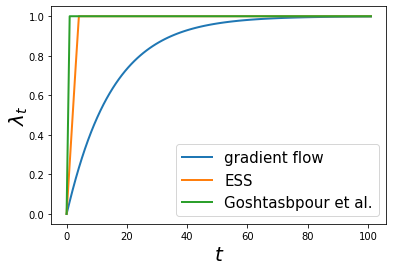

In [20]:
plt.plot(t*dt, lambda_opt, label = 'gradient flow', lw = 2)
plt.plot(t*dt, lambda_ess, label = 'ESS', lw = 2)
plt.plot(t*dt, lambda_gosh, label = 'Goshtasbpour et al.', lw = 2)
plt.legend(fontsize = 15)
plt.xlabel('$t$', fontsize = 20)
plt.ylabel('$\lambda_t$', fontsize = 20, labelpad=-1)
plt.savefig("lambda_ode_linear.pdf", bbox_inches='tight')

## Test for the sequence of $\lambda_t = 1- e^{\alpha t}$, $\alpha<0$ (negative exponentials)

In [5]:
tau = 2
alpha = 1/tau - 1

In [6]:
t = np.linspace(0, 10, 1000)
dt = t[1]-t[0]
lambda_ess = np.minimum(1 - np.exp(alpha * t), 1)

In [7]:
# lambda_opt = np.zeros(1000)


# for i in range(1, 1000):
#     var_opt = 0.5*(1/tau-1)**2*(1-lambda_opt[i-1]+lambda_opt[i-1]/tau)**(-2)
#     lambda_opt[i] = lambda_opt[i-1] + dt*(1-lambda_opt[i-1])*var_opt
        
tmp = []
l = 0
tmp.append(l)

while (l < 1):
    var_gosh = 0.5*(1/tau-1)**2*(1-tmp[-1]+tmp[-1]/tau)**(-2)
    l = tmp[-1] + dt*(var_gosh*(1-tmp[-1]))**(-1)
    tmp.append(l)
    
lambda_gosh = np.ones(1000)
lambda_gosh[:np.array(tmp).size] = tmp
lambda_gosh = np.minimum(lambda_gosh, 1)

In [8]:
def solve_lambda(t_final, dt, tau, lambda0=0.0):
    """
    Numerically solves
    dλ/dt = 0.5*(1/tau^2 - 1) * [1/(1-λ+λ/tau^2) - 1/(1-J+J/tau^2)]
             + (1-λ) * 0.5*(1/tau^2 - 1)**2 / (1-λ+λ/tau^2)**2
    where J(t) = ∫₀ᵗ e^(s-t) λ(s) ds
    """
    alpha = 0.5 * (1/tau**2 - 1)
    t_grid = np.arange(0, t_final, dt)
    lam = np.zeros_like(t_grid)
    lam[0] = lambda0
    J = 0.0  # initial integral value

    for i in range(1, len(t_grid)):
        # approximate J(t) using the trapezoid rule with exponential kernel
        J = J * np.exp(-dt) + 0.5 * dt * (lam[i-1] + lam[i-1]*np.exp(0))  # simple Euler update

        denom_lam = 1 - lam[i-1] + lam[i-1]/tau**2
        denom_J = 1 - J + J/tau**2

        dlam = alpha * (1/denom_lam - 1/denom_J) + (1 - lam[i-1]) * alpha**2 / denom_lam**2

        lam[i] = lam[i-1] + dlam * dt

    return t_grid, lam

# Example usage
t_opt, lambda_opt = solve_lambda(10, dt, tau, lambda0=0.0)

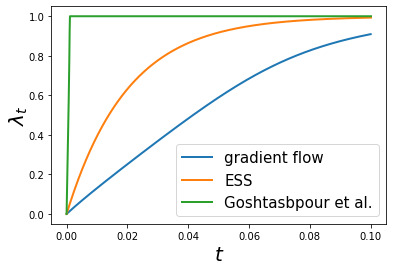

In [9]:
plt.plot(t_opt*dt, lambda_opt, label = 'gradient flow', lw = 2)
plt.plot(t*dt, lambda_ess, label = 'ESS', lw = 2)
plt.plot(t*dt, lambda_gosh, label = 'Goshtasbpour et al.', lw = 2)
plt.legend(fontsize = 15)
plt.xlabel('$t$', fontsize = 20)
plt.ylabel('$\lambda_t$', fontsize = 20, labelpad=-1)
plt.savefig("lambda_ode_neg_exp.pdf", bbox_inches='tight')

## Test for the sequence of $\lambda_t = e^{\alpha t}-1$, $\alpha>0$ (positive exponentials)

In [10]:
tau = 0.5
alpha = 1/tau - 1

In [11]:
t = np.linspace(0, 5, 1000)
dt = t[1]-t[0]
lambda_ess = np.minimum(np.exp(alpha * t) - 1, 1)

In [12]:
# lambda_opt = np.zeros(1000)

# for i in range(1, 1000):
#     var_opt = 0.5*(1/tau-1)**2*(1-lambda_opt[i-1]+lambda_opt[i-1]/tau)**(-2)
#     lambda_opt[i] = lambda_opt[i-1] + dt*(1-lambda_opt[i-1])*var_opt

tmp = []
l = 0
tmp.append(l)

while (l < 1):
    var_gosh = 0.5*(1/tau-1)**2*(1-tmp[-1]+tmp[-1]/tau)**(-2)
    l = tmp[-1] + dt*(var_gosh*(1-tmp[-1]))**(-1)
    tmp.append(l)
    
lambda_gosh = np.ones(1000)
lambda_gosh[:np.array(tmp).size] = tmp
lambda_gosh = np.minimum(lambda_gosh, 1)

In [13]:
t_opt, lambda_opt = solve_lambda(5, dt, tau, lambda0=0.0)

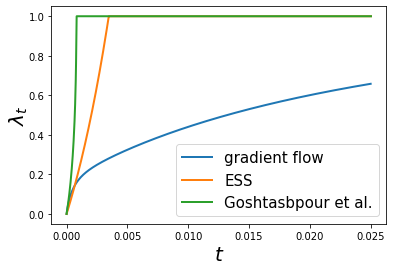

In [14]:
plt.plot(t_opt*dt, lambda_opt, label = 'gradient flow', lw = 2)
plt.plot(t*dt, lambda_ess, label = 'ESS', lw = 2)
plt.plot(t*dt, lambda_gosh, label = 'Goshtasbpour et al.', lw = 2)

plt.legend(fontsize = 15)
plt.xlabel('$t$', fontsize = 20)
plt.ylabel('$\lambda_t$', fontsize = 20, labelpad=-1)
plt.savefig("lambda_ode_pos_exp.pdf", bbox_inches='tight')